# Downloading GBIF Data with R and `rgbif`

### Interactive code and text generated by: Emily Black (emily@zoology.ubc.ca)
 (Some code and visualizations generated with the assistance of Claude Sonnet 5, last accessed Sept. 15, 2026)

 

Welcome! In this notebook we will search
and download species occurrence records from the
[Global Biodiversity Information Facility (GBIF)](https://www.gbif.org/). Using these records we will walk through a general cleaning workflow so they are ready for analysis. We'll also use the 
**`gbif.range`** function to make a species range map. 

**Workflow of the Notebook:**

0. Set up (and download) our packages
1. Select a species of your choice and pull occurrence records from GBIF
2. Map the records to see where they occur
3. Do some preliminary investigations of data quality using plots
4. Review the records for duplicates and records you would like to filter out
5. Generate a species range map with `gbif.range`
6. *If time allows:* animate how records have accumulated over time

> **Note:** every gray box below is a *code cell*. Click inside one, then press
> **Shift + Enter** to run it and move to the next cell. 

Keep an eye out for the discussion questions - we will pause to discuss these in small groups at the end of every few sections. 

## 0. Setup

Load the packages needed for the following workflow. Since we are working in MyBinder, they should already be loaded in our workspace.
If you are running this in your own R, uncomment the installation lines to install the packages - and note that `gbif.range` is installed from GitHub and not CRAN. 

In [102]:
# Uncomment these lines if the packages aren't already installed
# install.packages(c("rgbif", "dplyr", "ggplot2", "sf", "rnaturalearth",
#                     "rnaturalearthdata", "CoordinateCleaner", "terra",
#                     "remotes", "gganimate", "gifski"))
# remotes::install_github("8Ginette8/gbif.range", build_vignettes = FALSE)

suppressPackageStartupMessages({
library(rgbif) #downloads the GBIF data
library(dplyr) #data cleaning and processing
library(ggplot2) #data visualization
library(sf) #spatial data processing
library(rnaturalearth) #downloading earth maps
library(CoordinateCleaner) 
library(terra) #spatial data processing
library(gbif.range) #generating a range map from GBIF data
library(gganimate) #animating ggplot 
library(gifski) #generates GIFs
})


## 1. Pick a species and download its GBIF records

To get started, select your species! Type in the **scientific name** of any species 
you're curious about, then run the cell. It will:

1. Download that species' GBIF taxon key with `name_backbone()`. GBIF uses taxon keys instead of species names to look up records, so you will need to add this step when searching species. 
2. Download up to 2,000 occurrence records with coordinates using `occ_search()`. 

**Note:**: `occ_download()` from the `rgbif` package lets you download all records of the species of your choice. 
However, the download may take a long time, and it requires setting up your GBIF login details in R. 
For our sandbox, we will use `occ_search()`, but setup instructions for your GBIF credentials are in the Powerpoint slides. 


In [ ]:
# ---- EDIT ME ----
species_name <- "Lontra canadensis"   # <- type any scientific name here, e.g. "Danaus plexippus"
# --------------------

# Look up the GBIF taxon key for this species
key <- name_backbone(name = species_name)$usageKey

# Download up to 2000 georeferenced occurrence records
occ_data <- occ_search(taxonKey = key, limit = 2000, hasCoordinate = TRUE) #hasCoordinate ensures we get records with lat/lon data
#occ_search outputs a list, so we need to get our data into a dataframe
occ_df <- occ_data$data

#how many rows and columns do our data have? 
#what do our data look like? 
nrow(occ_df)
head(occ_df)


[1] 2000

key,scientificName,decimalLatitude,decimalLongitude,issues,datasetKey,publishingOrgKey,X.CitizenScience.,installationKey,hostingOrganizationKey,⋯,http...unknown.org.maxSearchResponseRecords,bibliographicCitation,higherClassification,X.eDNA.,associatedSequences,taxonConceptID,http...unknown.org.datasetCategory.gbif.org,recordNumber,fieldNumber,eventRemarks
<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
6185861734,"Choristoneura fumiferana (Clemens, 1865)",40.03364,-76.41159,"cdc,cdround",50c9509d-22c7-4a22-a47d-8c48425ef4a7,28eb1a3f-1c15-4a95-931a-4af90ecb574d,CitizenScience,997448a8-f762-11e1-a439-00145eb45e9a,28eb1a3f-1c15-4a95-931a-4af90ecb574d,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
6413585717,"Choristoneura fumiferana (Clemens, 1865)",39.13668,-123.20230,"cdc,cdround",50c9509d-22c7-4a22-a47d-8c48425ef4a7,28eb1a3f-1c15-4a95-931a-4af90ecb574d,CitizenScience,997448a8-f762-11e1-a439-00145eb45e9a,28eb1a3f-1c15-4a95-931a-4af90ecb574d,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
6195871682,"Choristoneura fumiferana (Clemens, 1865)",47.38289,-91.20799,"cdc,cdround",50c9509d-22c7-4a22-a47d-8c48425ef4a7,28eb1a3f-1c15-4a95-931a-4af90ecb574d,CitizenScience,997448a8-f762-11e1-a439-00145eb45e9a,28eb1a3f-1c15-4a95-931a-4af90ecb574d,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
6352356338,"Choristoneura fumiferana (Clemens, 1865)",41.21892,-75.84230,"cdc,cdround",50c9509d-22c7-4a22-a47d-8c48425ef4a7,28eb1a3f-1c15-4a95-931a-4af90ecb574d,CitizenScience,997448a8-f762-11e1-a439-00145eb45e9a,28eb1a3f-1c15-4a95-931a-4af90ecb574d,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
6352782402,"Choristoneura fumiferana (Clemens, 1865)",41.81933,-88.11239,"cdc,cdround",50c9509d-22c7-4a22-a47d-8c48425ef4a7,28eb1a3f-1c15-4a95-931a-4af90ecb574d,CitizenScience,997448a8-f762-11e1-a439-00145eb45e9a,28eb1a3f-1c15-4a95-931a-4af90ecb574d,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
6398720040,"Choristoneura fumiferana (Clemens, 1865)",42.78226,-78.75423,"cdc,cdround",50c9509d-22c7-4a22-a47d-8c48425ef4a7,28eb1a3f-1c15-4a95-931a-4af90ecb574d,CitizenScience,997448a8-f762-11e1-a439-00145eb45e9a,28eb1a3f-1c15-4a95-931a-4af90ecb574d,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


## 2. Map the occurrence records

After investigating your dataframe, you will likely want to map your uncleaned occurrence records to see where they are. 

The code below zooms the map to fit wherever your species was recorded. 
This is done by getting a bounding box from the min/max longitude and latitude in your data,
and adding a bit of extra space.

This works automatically, no matter which species you searched!

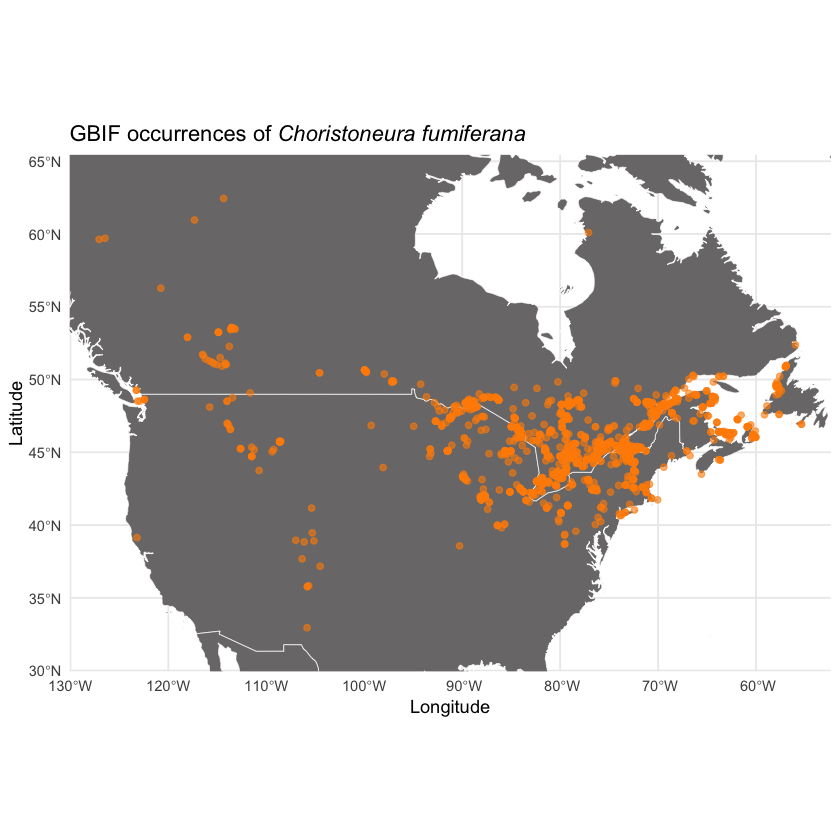

In [104]:
world <- ne_countries(scale = "medium", returnclass = "sf") #download a map of the world

# Record the extent of the observations, then add a bit of space around it
pad <- 3  # 3 degrees of latitude and longitude padding around the range of the records
lon_range <- range(occ_df$decimalLongitude, na.rm = TRUE)
lat_range <- range(occ_df$decimalLatitude, na.rm = TRUE)

#plot our range map: 
ggplot() +
  geom_sf(data = world, fill = "#7a7878", color = "white") + #this ggplot function plots spatial data - this is our background map 
  geom_point( #geom_point plots our occurrence records on top of the background map
    data = occ_df,
    aes(x = decimalLongitude, y = decimalLatitude),
    color = "darkorange", alpha = 0.6, size = 1.5
  ) + 
  coord_sf(
    xlim = c(lon_range[1] - pad, lon_range[2] + pad),
    ylim = c(lat_range[1] - pad, lat_range[2] + pad),
    expand = FALSE
  ) + #this function sets the limit of the map, adding the extra space with "pad"
  theme_minimal() +
labs(
    title = bquote("GBIF occurrences of " * italic(.(species_name))),
    x = "Longitude", y = "Latitude"
  )


## 3. Preliminary data plots

Before proceeding with analyzing the data, it's worth taking a moment to investigate where and when the data are coming from and if there are any red flags. 

Let's make two plots: 

- **Records by month** — what is the temporal coverage of the data? Note that you can easily change this to year if you are interested in that as well. 
- **Records by data source (`basisOfRecord`)** — are these preserved museum specimens,
  human observations, machine observations, or something else? Do these records match what you expect and would like to use? 

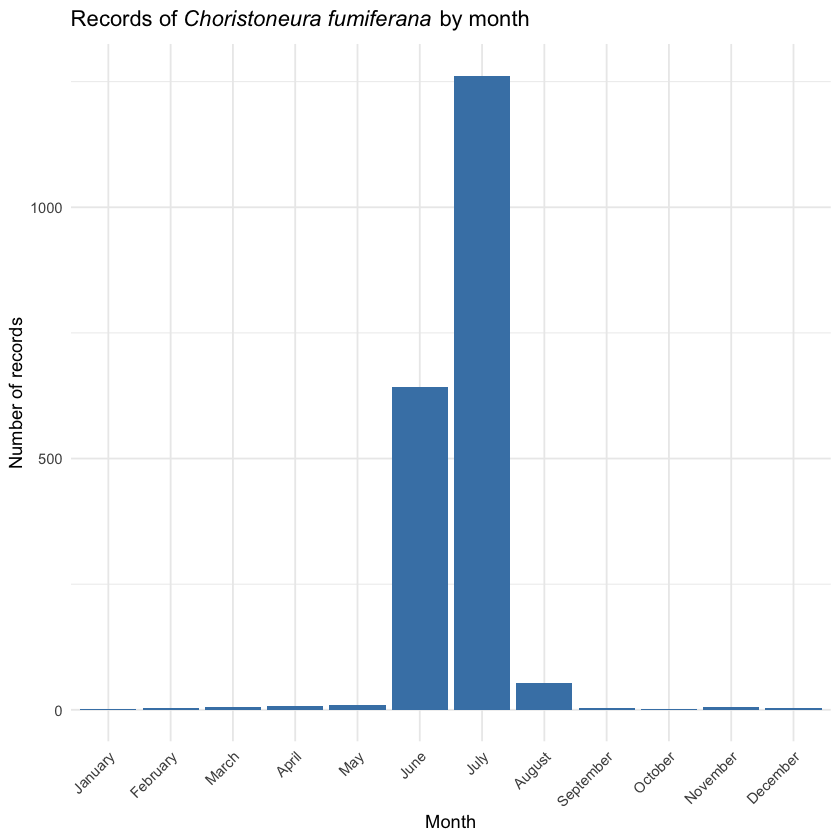

In [105]:
#Make a histogram of the month of observation: 
occ_df %>%
  filter(!is.na(month)) %>%
  count(month) %>%
  mutate(month = factor(month.name[month], levels = month.name)) %>%
  ggplot(aes(x = month, y = n)) +
  geom_col(fill = "steelblue") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  labs(
    title = bquote("Records of " * italic(.(species_name)) * " by month"),
    x = "Month", y = "Number of records"
  )

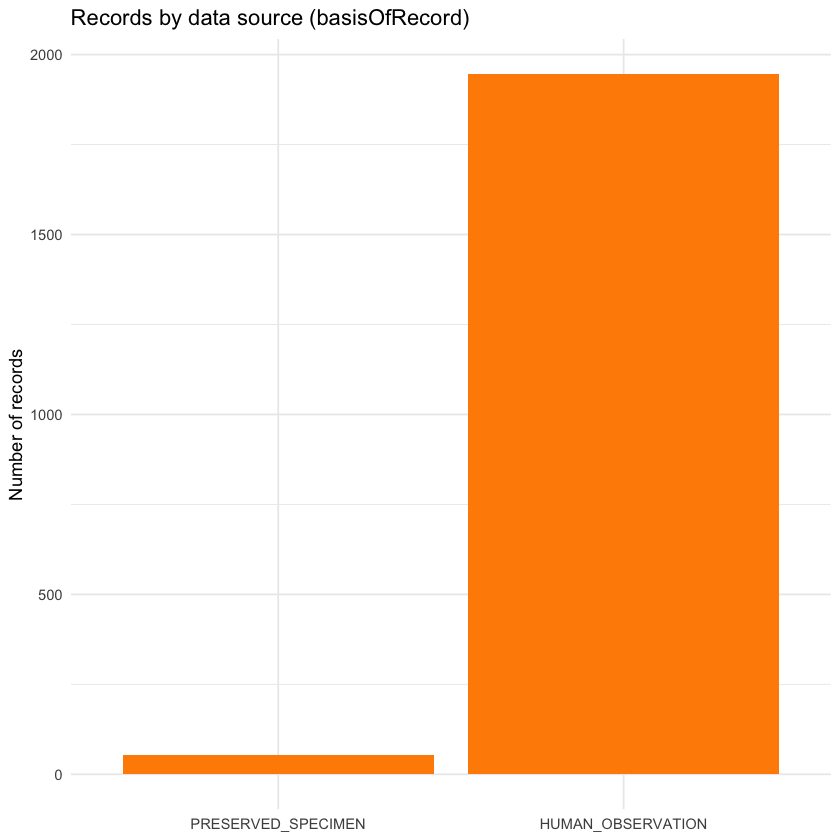

In [106]:
#plot the data source
occ_df %>%
  count(basisOfRecord, sort = TRUE) %>%
  ggplot(aes(x = reorder(basisOfRecord, n), y = n)) +
  geom_col(fill = "darkorange") +
  theme_minimal() +
  labs(
    title = "Records by data source (basisOfRecord)",
    x = NULL, y = "Number of records"
  )


### Discussion Questions

1. Consider your species of interest and the GBIF data you may download for your research. What kinds of data checks and visualizations would be important to perform before proceeding with your analyses? 

2. For the species you selected above, do you notice that the data are heavily skewed towards one data source or time of year? Do you have any theories as to why that may be?

3. Let's say you need to download GBIF records for a species that has a lot (10,000+) of observations. How might you adjust your data checks to ensure you can catch any errors or funniness in the data? 



## 4A. Cleaning GBIF Records: Checking for errors and filtering out data you don't want

There can be issues with GBIF records.

 In particular, there are two common problems you will encounter frequently: 
 - **Duplicate records** - the same observation submitted more than once or to more than one dataset (e.g. if someone on iNaturalist uploaded the same image twice). 
- **Captive or cultivated individuals** - a zoo animal or a garden plant which does not belong to a wild population, but is uploaded to a biodiversity database. These can skew the distribution of your species; for example, let's take a look at <i>Rosa chinensis</i>, a rose species whose wild range is Southwestern China: 


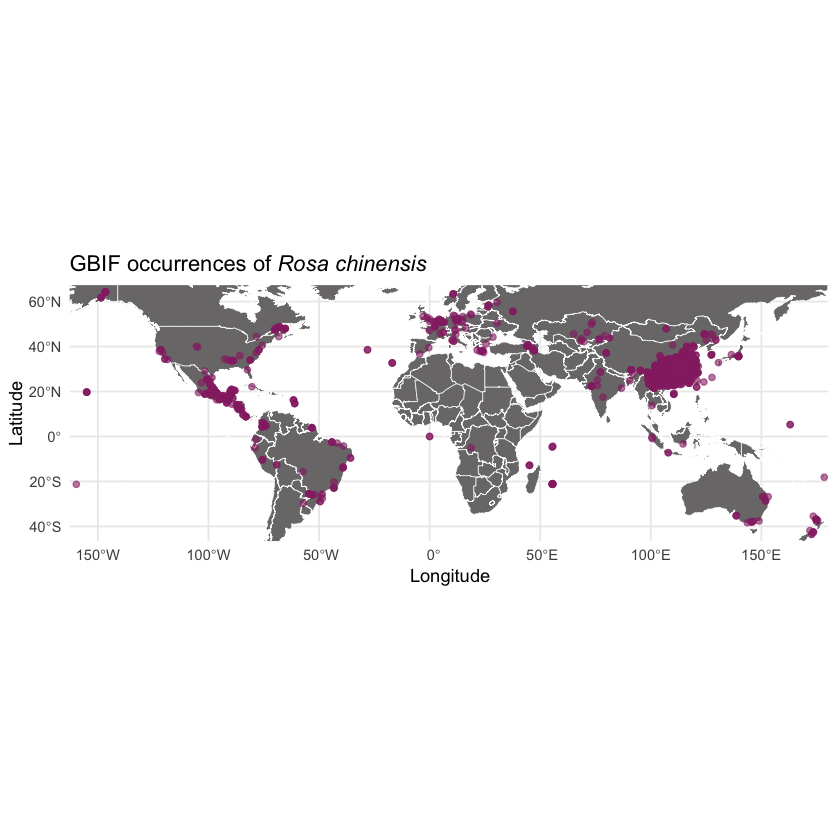

In [107]:
#Download rose records from GBIF
rose_name <- "Rosa chinensis"  
rose_key <- name_backbone(name = rose_name)$usageKey
rose_data <- occ_search(taxonKey = rose_key, limit = 2000, hasCoordinate = TRUE)
rose_df <- rose_data$data

#plot rose records on a map
lon_range <- range(rose_df$decimalLongitude, na.rm = TRUE)
lat_range <- range(rose_df$decimalLatitude, na.rm = TRUE)

#plot our range map: 
ggplot() +
  geom_sf(data = world, fill = "#7a7878", color = "white") + #this ggplot function plots spatial data - this is our background map 
  geom_point( #geom_point plots our occurrence records on top of the background map
    data = rose_df,
    aes(x = decimalLongitude, y = decimalLatitude),
    color = "#962c73", alpha = 0.6, size = 1.5
  ) + 
  coord_sf(
    xlim = c(lon_range[1] - pad, lon_range[2] + pad),
    ylim = c(lat_range[1] - pad, lat_range[2] + pad),
    expand = FALSE
  ) + #this function sets the limit of the map, adding the extra space with "pad"
  theme_minimal() +
labs(
    title = bquote("GBIF occurrences of " * italic(.(rose_name))),
    x = "Longitude", y = "Latitude"
  )



To deal with these issues, we have a few approaches we can use. 

Using the `rgbif` package, we can sometimes filter out captive and cultivated records using the **establishmentMeans** column. If available, GBIF populates this field with information about whether our records are wild or not. 

If you suspect the records are mostly from iNaturalist, you may prefer to use a column with this information imported directly from iNaturalist. In that case, we can use: **http...unknown.org.captive_cultivated** - the url-style column name indicates this is being downloaded from a non-GBIF site. 

To illustrate the cleaning steps above, we will test it with the rose dataframe: 

In [108]:
# First, check for captive and cultivated specimens using "establishmentMeans" if that column is available to us: 
table(rose_df$establishmentMeans, useNA = "ifany")
#You can also check for captive and cultivated records using the imported iNaturalist column: 
table(rose_df$"http...unknown.org.captive_cultivated", useNA = "ifany")


introduced  uncertain       <NA> 
        14          1       1922 


wild <NA> 
  18 1919 

To run a broader check, we can use the `clean_coordinates` function. This is from the [`CoordinateCleaner`](https://besjournals.onlinelibrary.wiley.com/doi/10.1111/2041-210X.13152?__cf_chl_tk=K.L8rqDsoQyIBU34H.kn5ZZcFHJyAoUdaRhg4y9pVug-1789496280-1.0.1.1-Q7QLSUSDo255mIbSdBTYSZ8xSWFlDujQ5qhG.LYqdbI) package, which has "tests" which help with cleaning GBIF data. It can check for duplicated occurrence records, records with blatant errors in data entry (e.g. identical latitude and longitude), individuals that may not be marked as captive but sit on top of zoos and gardens, and others. 

A few of the most useful options are indicated in the data cleaning code below. Apply them to the species of your choice: 

In [109]:
# Run a broader automated check for common coordinate problems:
# - duplicates:    repeated records
# - equal:         identical lat/lon (often a data-entry error)
# - gbif:          coordinates sitting on GBIF's headquarters
# - institutions:  coordinates sitting on museums, zoos, or universities (often captive individuals)
# - zeros:         coordinates at (0,0) or missing
flags <- clean_coordinates(
  x = occ_df,
  lon = "decimalLongitude",
  lat = "decimalLatitude",
  species = "species",
  tests = c("duplicates", "equal", "gbif", "institutions", "zeros")
)

summary(flags) #this lets you know if there are issues in your dataframe



Testing coordinate validity

Flagged 0 records.

Testing equal lat/lon

Flagged 0 records.

Testing zero coordinates

Warning message:
“[vect] guessed crs”
Flagged 0 records.

Testing GBIF headquarters, flagging records around Copenhagen

Flagged 0 records.

Testing biodiversity institutions

Flagged 7 records.

Testing duplicates

Flagged 449 records.

Flagged 454 of 2000 records, EQ = 0.23.



.val     .equ     .zer     .gbf    .inst     .dpl .summary 
       0        0        0        0        7      449      454

## 4B. Your own data cleaning and curation

Now that you are familiar with the data cleaning pipeline, it's your chance to clean up your own records as you choose!

In the code chunks below and following the instructions above, modify your data cleaning pipeline to customize the records in your final dataset. 



In [110]:
# ============================================================
# BUILD YOUR OWN PIPELINE
# Edit any of the settings below, then run the whole section
# ============================================================

# ----  EDIT ME: species ----
my_species <- species_name   # reuse your species from earlier, or type a new one

# ----  EDIT ME: filters ----
# All of these will end up in the occ_search() function, so you can edit them to your liking
my_country       <- NULL                                   # Country filter: e.g. "US", "CA", "MX" — or NULL for no country filter
my_basis_of_record <- c("HUMAN_OBSERVATION")  
                                                             # options include:
                                                             # "HUMAN_OBSERVATION", "PRESERVED_SPECIMEN",
                                                             # "MACHINE_OBSERVATION", "FOSSIL_SPECIMEN",
                                                             # "MATERIAL_SAMPLE", "OBSERVATION"
my_year_min      <- 2024                                   # earliest year to include
my_year_max      <- 2026                                   # latest year to include
my_limit         <- 2000                                   # how many records to request. You can select up to 100,000 records (but I'd reccommend 1000-10,000 for our purposes!)

# ---- Look up the taxon key ----
my_key <- name_backbone(name = my_species)$usageKey

# ---- Run the customized search ----
my_occ <- occ_search(
  taxonKey = my_key,
  country = my_country,
  basisOfRecord = my_basis_of_record,
  year = paste0(my_year_min, ",", my_year_max),
  hasCoordinate = TRUE,
  limit = my_limit
)

my_df <- my_occ$data

nrow(my_df)


[1] 1068

In [111]:
# ---- EDIT ME: which CoordinateCleaner tests to run? ----
my_tests <- c("duplicates", "equal", "gbif", "institutions", "zeros")
                                                 # other options include: 
                                                 #"capitals", #is there a concern observations are being assigned to the capital of a country instead of a real location?
                                                 # "centroids": is there a concern observations are being assigned to the centre of a country instead of a real location? 
                                                 # "seas": is your terrestrial species being recorded in the ocean?
                                                 #"urban": are your observations in an urban area? 

my_flags <- clean_coordinates(
  x = my_df,
  lon = "decimalLongitude",
  lat = "decimalLatitude",
  species = "species",
  tests = my_tests
)

#what red flags did we identify in the data? 
summary(my_flags)

#filter out the records that failed any of the tests
my_clean <- my_df[my_flags$.summary, ]
data.frame(clean_rows = nrow(my_clean))

Testing coordinate validity

Flagged 0 records.

Testing equal lat/lon

Flagged 0 records.

Testing zero coordinates

Warning message:
“[vect] guessed crs”
Flagged 0 records.

Testing GBIF headquarters, flagging records around Copenhagen

Flagged 0 records.

Testing biodiversity institutions

Flagged 6 records.

Testing duplicates

Flagged 191 records.

Flagged 195 of 1068 records, EQ = 0.18.



.val     .equ     .zer     .gbf    .inst     .dpl .summary 
       0        0        0        0        6      191      195

clean_rows
<int>
873


### Discussion Questions: 

1. Take a look at the options available for the `clean_coordinates()` function. Which of these filters do you feel will be most important to apply to your study species? 

2. There is no perfect way to deal with species which are commonly captive and cultured, as filtering relies on people labelling observations correctly or being within a garden or zoo. Do you feel GBIF data can be used to make accurate wild range maps of these species (e.g. axolotl, rose)? Is there any appropriate way to map and analyze these species, or should we generally avoid their GBIF records when it is important to only include wild specimens? 

3. For a general GBIF cleaning workflow, in your view what are the most important steps to take to ensure your data is of high quality? 

## 5. Estimate a species range map with `gbif.range`

We can turn these scattered occurrence points into an estimated range map.
The [`gbif.range`](https://github.com/8Ginette8/gbif.range) package does this by combining
our (cleaned) occurrence points with a set of **ecoregions** - areas of the world with
broadly similar ecology. It essentially asks: "which ecoregions has this species
been recorded in, accounting for outliers?" and shades those in.

The first line below downloads a set of global terrestrial ecoregions. This step, and the range estimation, can take a minute or two.

**Note:** `gbif.range` needs you to define what habitat your species lives in. If your species is aquatic (marine or freshwater), adjust the code below to either `eco_marine` or `eco_fresh`, and adjust the `ecoreg_name ` line following the instructions in the comments. See the [package README](https://github.com/8Ginette8/gbif.range#available-ecoregions) for more details.

In [112]:
# Download terrestrial ecoregions
eco_terra <- read_ecoreg(ecoreg_name = "eco_terra", save_dir = NULL) #adjust to eco_marine or eco_fresh if your species is not terrestrial

# Estimate the species range from our cleaned occurrence records
species_range <- get_range(
  occ_coord = my_clean,
  ecoreg = eco_terra, #adjust to eco_marine or eco_fresh if your species is not terrestrial
  ecoreg_name = "ECO_NAME", #if terrestrial, use "ECO_NAME"; if marine or fresh, use "ECOREGION"
  degrees_outlier = 5,     # treat records more than ~550 km from the main cluster as outliers
  clust_pts_outlier = 4    # ignore small isolated clusters of fewer than 4 records
)


Warning message:
“Unknown or uninitialised column: `input_search`.”
## Start of computation for species:  ###

9 outlier's from 707 | proportion from total points: 1%

ecoregion 1 of 19: Aspen Parkland

ecoregion 2 of 19: Boreal Plains

ecoregion 3 of 19: Boreal Shield

ecoregion 4 of 19: Canadian Rocky Mountains

ecoregion 5 of 19: Central Appalachian Forest

ecoregion 6 of 19: Fescue-Mixed Grass Prairie

ecoregion 7 of 19: Great Lakes

ecoregion 8 of 19: High Allegheny Plateau

ecoregion 9 of 19: Lower New England / Northern Piedmont

ecoregion 10 of 19: North Atlantic Coast

ecoregion 11 of 19: North Central Tillplain

ecoregion 12 of 19: Northern Appalachian / Acadian

ecoregion 13 of 19: Northern Tallgrass Prairie

ecoregion 14 of 19: Prairie-Forest Border

ecoregion 15 of 19: Southern Rocky Mountains

ecoregion 16 of 19: St. Lawrence - Champlain Valley

ecoregion 17 of 19: Superior Mixed Forest

ecoregion 18 of 19: Western Allegheny Plateau

ecoregion 19 of 19: Willamette Valley 

You will notice that in the scrolling text below this function it is listing ecoregions our organism is found in. You can learn more about where these regions came from, and the package itself, at [`this preprint`](https://www.authorea.com/doi/full/10.22541/au.175130858.83083354/v1).

Moment of truth: let's generate a species range map! 

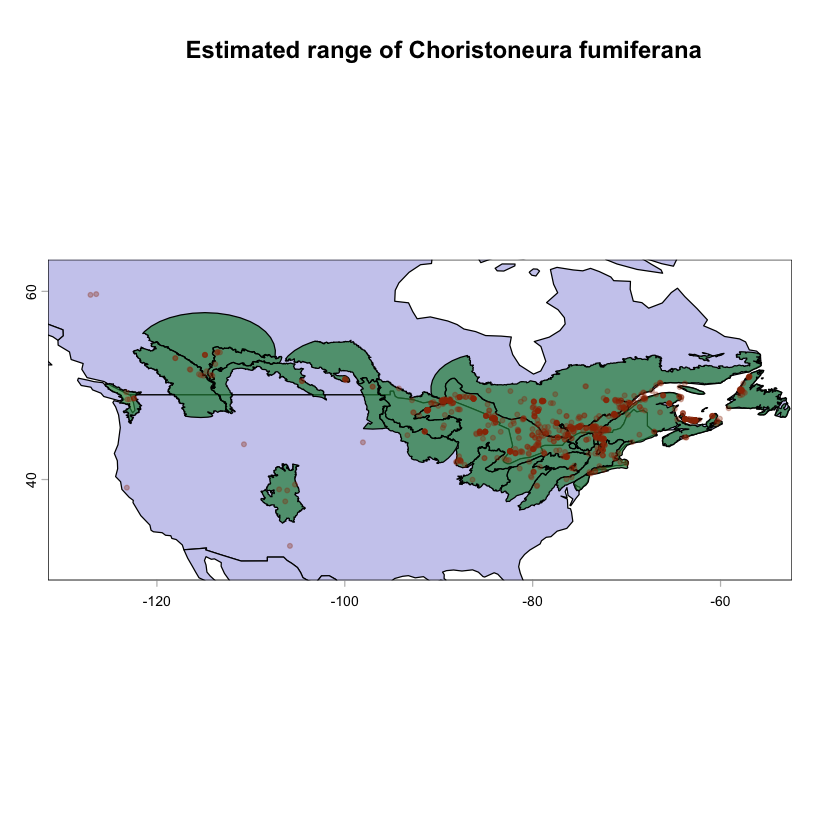

In [113]:
countries_sv <- ne_countries(type = "countries", returnclass = "sv")

# Zoom to the extent of the occurrence records, with a little padding
range_pad <- 3
range_lon <- range(my_clean$decimalLongitude, na.rm = TRUE)
range_lat <- range(my_clean$decimalLatitude, na.rm = TRUE)

terra::plot(
  countries_sv, col = "#cccdee",
  xlim = c(range_lon[1] - range_pad, range_lon[2] + range_pad),
  ylim = c(range_lat[1] - range_pad, range_lat[2] + range_pad)
)
terra::plot(species_range$rangeOutput, col = "#238b45", add = TRUE, legend = FALSE, alpha = 0.7)
points(my_clean$decimalLongitude, my_clean$decimalLatitude, pch = 20, col = "#99340450", cex = 0.8)
title(paste("Estimated range of", species_name))


### Discussion Questions

1. For the species you selected, look up its actual distribution online. How close is the map you generated above to its real range? 

2. What caveats could you see with the approach of selecting entire ecoregions to create a species distribution? In what contexts would this map be appropriate, and in what contexts would this map not be very useful? 

3. In the presentation, we discussed how biodiversity datasets can have a strong urban bias. How might that affect our ability to model species ranges using records from GBIF/other biodiversity datasets? 

## 6. Bonus: animate how records accumulated over time

If you have extra time or are looking for more fun ways to visualize GBIF records, we can animate the records appearing over time to see when each observation appears and where. 

First, take just records from the
earliest month, then that month plus the next, and so on. We do this by building a
"cumulative" version of the data (each record repeated in every frame from its month
onward) and animating it with `gganimate`.

In [117]:
# Recompute the crop extent based on the data we're actually animating
anim_lon_range <- range(my_clean$decimalLongitude, na.rm = TRUE)
anim_lat_range <- range(my_clean$decimalLatitude, na.rm = TRUE)
anim_pad <- 3

my_clean$year_month <- sprintf("%04d-%02d", my_clean$year, my_clean$month)

months_present <- sort(unique(my_clean$year_month[!is.na(my_clean$year_month)]))

cumulative_list <- lapply(months_present, function(ym) {
  d <- my_clean[!is.na(my_clean$year_month) & my_clean$year_month <= ym, ]
  d$frame_month <- ym
  d
})
cumulative_df <- do.call(rbind, cumulative_list)

anim_plot <- ggplot() +
  geom_sf(data = world, fill = "gray95", color = "white") +
  geom_point(
    data = cumulative_df,
    aes(x = decimalLongitude, y = decimalLatitude),
    color = "darkorange", alpha = 0.6, size = 1.5
  ) +
  coord_sf(
    xlim = c(anim_lon_range[1] - anim_pad, anim_lon_range[2] + anim_pad),
    ylim = c(anim_lat_range[1] - anim_pad, anim_lat_range[2] + anim_pad),
    expand = FALSE
  ) +
  theme_minimal() +
  labs(
    title = "GBIF records through {closest_state}",
    x = "Longitude", y = "Latitude"
  ) +
  transition_states(frame_month, transition_length = 1, state_length = 1) +
  ease_aes("linear")

animate(
  anim_plot,
  nframes = length(months_present) * 2,
  fps = 4,
  width = 700, height = 500,
  renderer = gifski_renderer()
)

## Even more time? Try it all again!

Scroll back up to **Section 1**, change `species_name` to something new, and use
**Kernel → Restart & Run All** to rerun the whole workflow from scratch for a different
species!

## Resources

- [`rgbif` documentation](https://docs.ropensci.org/rgbif/) — the core GBIF search/download package
- [GBIF.org](https://www.gbif.org/) — browse occurrence data directly in your browser
- [`CoordinateCleaner` documentation](https://docs.ropensci.org/CoordinateCleaner/) — automated data-quality checks
- [`gbif.range` GitHub repository](https://github.com/8Ginette8/gbif.range) — ecoregion-based range mapping
- [`rnaturalearth` documentation](https://docs.ropensci.org/rnaturalearth/) — basemaps and country boundaries
- [`gganimate` documentation](https://gganimate.com/) — animating ggplot2 figures

Code and visualizations generated with the assistance of Claude Sonnet 5 (last accessed Sept. 15th 2026)
